In [24]:
from shapely.geometry import Point, LineString, Polygon

p1 = Point(2.2,4.2)
p2 = Point(7.2, -25.1)
p3 = Point(9.26, -2.456)

street_segment = LineString([p1, p2, p3])
print("street segment length:",street_segment.length)

park_zone = Polygon([p1, p2, p3,p1])  

print("park zone validity:",park_zone.is_valid)

distance = p1.distance(p2)
print("distance between p1 and p2:", distance)



street segment length: 52.46106912939557
park zone validity: True
distance between p1 and p2: 29.723559679150142


In [18]:
import pandas as pd
import geopandas as gpd

buildings= {
    "name": ["library", "stadium", "plaza"],"longitude": [139.70, 139.76, 139.75],"latitude": [35.67, 35.70, 35.69]
}

dataframe = pd.DataFrame(buildings)
print("dataframe :",dataframe)
geometry = gpd.points_from_xy(dataframe.longitude, dataframe.latitude)
print("deometry:",geometry)
gdf_landmarks = gpd.GeoDataFrame(dataframe, geometry=geometry,crs="EPSG:4326")
print("geodataFrame:",gdf_landmarks)

print("type of gdf_landmarks:", type(gdf_landmarks))
print("type of gdf_landmarks geometry column:", type(gdf_landmarks.geometry.iloc[0]))



dataframe :       name  longitude  latitude
0  library     139.70     35.67
1  stadium     139.76     35.70
2    plaza     139.75     35.69
deometry: <GeometryArray>
[<POINT (139.7 35.67)>, <POINT (139.76 35.7)>, <POINT (139.75 35.69)>]
Length: 3, dtype: geometry
geodataFrame:       name  longitude  latitude              geometry
0  library     139.70     35.67   POINT (139.7 35.67)
1  stadium     139.76     35.70   POINT (139.76 35.7)
2    plaza     139.75     35.69  POINT (139.75 35.69)
type of gdf_landmarks: <class 'geopandas.geodataframe.GeoDataFrame'>
type of gdf_landmarks geometry column: <class 'shapely.geometry.point.Point'>


<Axes: >

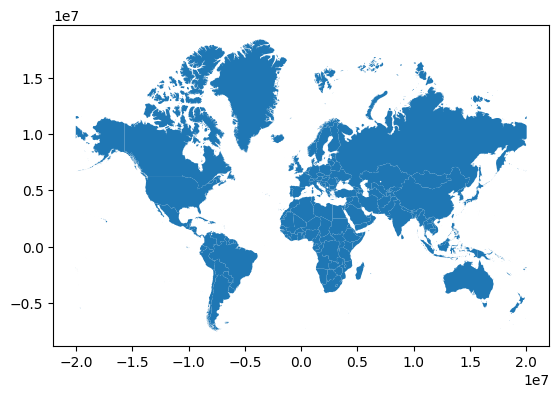

In [22]:
countries = gpd.read_file("../data/Countries/countries_clean.gpkg")
countries.plot()


<Axes: >

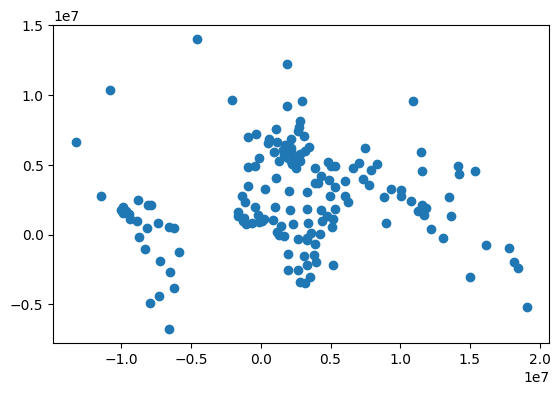

In [23]:
countries["centroid"] = countries.geometry.centroid
countries = countries.set_geometry("centroid")
countries.plot()